# **Instructions for Dataset Setup**

To run this notebook, you need to first download the dataset from the shared Google Drive link:

[Shared Melanoma Dataset](https://drive.google.com/drive/folders/1kLYAv9jxFuBII54V8XChU7i9a2x-wLAC)

Steps:

Click the link above to open the shared folder.
Download the train and test folders to your own Google Drive.
Create a folder named melanoma in your Drive, and place the downloaded train and test folders inside it.
After this, the notebook will automatically use the following paths:



*   train_dir = "/content/drive/MyDrive/melanoma/train"
*   val_dir   = "/content/drive/MyDrive/melanoma/test"
*   save_model_dir = "/content/drive/MyDrive/melanoma/vit_skin_model"





# **Connect to Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Training**

In [3]:
# --------------------------------------
# Minimal ViT Training Functional
# --------------------------------------
import os, time
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
from transformers import AutoImageProcessor, AutoModelForImageClassification, pipeline
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import numpy as np
from tqdm import tqdm

# ---------- Paths ----------
train_dir = "/content/drive/MyDrive/melanoma/train"
val_dir   = "/content/drive/MyDrive/melanoma/test"
save_model_dir = "/content/drive/MyDrive/melanoma/vit_skin_model"

# ---------- Dataset ----------
class SkinDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_paths, self.labels = [], []
        self.transform = transform
        for label, folder in enumerate(["benign", "malignant"]):
            folder_path = os.path.join(img_dir, folder)
            if not os.path.exists(folder_path):
                raise ValueError(f"Folder not found: {folder_path}")
            for img_file in os.listdir(folder_path):
                self.img_paths.append(os.path.join(folder_path, img_file))
                self.labels.append(label)
    def __len__(self): return len(self.img_paths)
    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, torch.tensor(self.labels[idx])

# ---------- Transformations & DataLoader ----------
processor = AutoImageProcessor.from_pretrained("Kuldeepmishra3/vit-large-skin-cancer-ham10000")
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),  # Must match model input
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

train_loader = DataLoader(SkinDataset(train_dir, transform=preprocess), batch_size=2, shuffle=True)
val_loader   = DataLoader(SkinDataset(val_dir, transform=preprocess), batch_size=2)

# ---------- Load ViT-large ----------
model = AutoModelForImageClassification.from_pretrained(
    "Kuldeepmishra3/vit-large-skin-cancer-ham10000",
    num_labels=2,
    ignore_mismatched_sizes=True,
    from_tf=False
)

# Fine-tune only the classifier
for p in model.parameters(): p.requires_grad = False
for p in model.classifier.parameters(): p.requires_grad = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ---------- Training (1 Epoch) ----------
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.classifier.parameters(), lr=1e-5)
epochs = 1

for epoch in range(epochs):
    start_epoch = time.time()
    model.train()
    total_loss = 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} - Training"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} - Validation"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs).logits
        probs = torch.softmax(outputs, dim=1)[:,1]
        preds = torch.argmax(outputs, dim=1)
        # detach to numpy
        all_labels.extend(labels.cpu().detach().numpy())
        all_preds.extend(preds.cpu().detach().numpy())
        all_probs.extend(probs.cpu().detach().numpy())

    all_labels, all_preds, all_probs = np.array(all_labels), np.array(all_preds), np.array(all_probs)

    # Metrics
    acc = (all_preds==all_labels).mean()
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    conf_matrix = confusion_matrix(all_labels, all_preds)
    try:
        roc_auc = roc_auc_score(all_labels, all_probs)
    except:
        roc_auc = float('nan')

    elapsed = time.time() - start_epoch
    print(f"Epoch {epoch+1} completed in {elapsed:.1f}s | Loss: {avg_loss:.4f} | Accuracy: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-score: {f1:.4f} | ROC/AUC: {roc_auc:.4f}")
    print("Confusion Matrix:\n", conf_matrix)

# ---------- Save Model ----------
os.makedirs(save_model_dir, exist_ok=True)
model.save_pretrained(save_model_dir)
processor.save_pretrained(save_model_dir)
print("Model saved at:", save_model_dir)

# ---------- Prediction Pipeline ----------
classifier = pipeline("image-classification", model=save_model_dir, feature_extractor=save_model_dir)
# result = classifier("/content/drive/MyDrive/proyecto - transformer/nuevo_lunar.jpg")
# print(result)

config.json:   0%|          | 0.00/881 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: Kuldeepmishra3/vit-large-skin-cancer-ham10000
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([7]) vs model:torch.Size([2])            
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([7, 1024]) vs model:torch.Size([2, 1024])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
Epoch 1/1 - Validation: 100%|██████████| 500/500 [07:27<00:00,  1.12it/s]

Epoch 1 completed in 4473.0s | Loss: 0.4287 | Accuracy: 0.8660 | Precision: 0.9103 | Recall: 0.8120 | F1-score: 0.8584 | ROC/AUC: 0.9381
Confusion Matrix:
 [[460  40]
 [ 94 406]]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved at: /content/drive/MyDrive/melanoma/vit_skin_model


Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

# **Confusion Matrix as Heatmap**

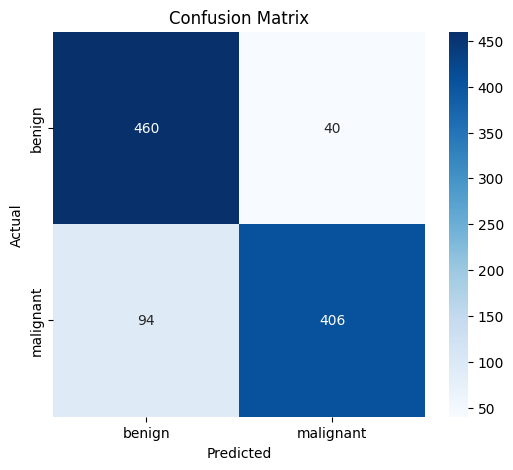

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Suponiendo que all_labels y all_preds ya están calculados
cm = confusion_matrix(all_labels, all_preds)
labels = ["benign", "malignant"]  # Nombres de tus clases

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# **ROC Curve**

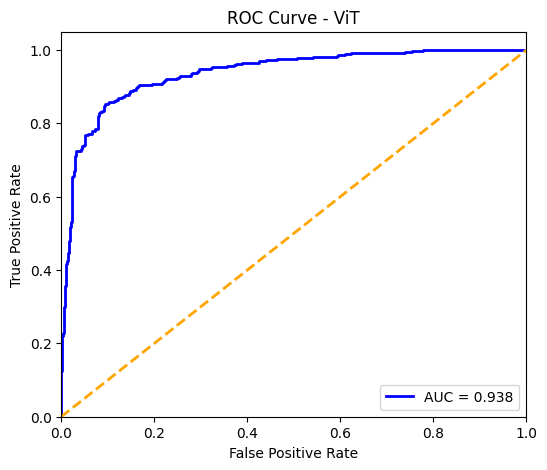

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# all_labels: etiquetas verdaderas
# all_probs: probabilidades de clase positiva

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], color='orange', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ViT')
plt.legend(loc='lower right')
plt.show()

# **Verification / Prediction**

In [13]:
# ---------- Verification / Prediction Block ----------
from google.colab import files
from transformers import pipeline

# ---------- Load pipeline ----------
classifier = pipeline(
    "image-classification",
    model="/content/drive/MyDrive/melanoma/vit_skin_model",
    feature_extractor="/content/drive/MyDrive/melanoma/vit_skin_model"
)

# ---------- Class mapping ----------
class_map = { "LABEL_0": "benign", "LABEL_1": "malignant" }

# ---------- Upload image ----------
uploaded = files.upload()  # Se abre diálogo para seleccionar imagen
for filename in uploaded.keys():
    print(f"Image uploaded: {filename}")

    # ---------- Prediction ----------
    result = classifier(filename)

    # Map label
    label_raw = result[0]['label']
    label = class_map.get(label_raw, label_raw)
    score = result[0]['score']

    print(f"The model predicts this lesion as {label.upper()} with confidence {score*100:.2f}%")

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

Saving mali.jpg to mali.jpg
Image uploaded: mali.jpg
The model predicts this lesion as MALIGNANT with confidence 72.57%


In [14]:
# ---------- Verification / Prediction Block ----------
from google.colab import files
from transformers import pipeline

# ---------- Load pipeline ----------
classifier = pipeline(
    "image-classification",
    model="/content/drive/MyDrive/melanoma/vit_skin_model",
    feature_extractor="/content/drive/MyDrive/melanoma/vit_skin_model"
)

# ---------- Class mapping ----------
class_map = { "LABEL_0": "benign", "LABEL_1": "malignant" }

# ---------- Upload image ----------
uploaded = files.upload()  # Se abre diálogo para seleccionar imagen
for filename in uploaded.keys():
    print(f"Image uploaded: {filename}")

    # ---------- Prediction ----------
    result = classifier(filename)

    # Map label
    label_raw = result[0]['label']
    label = class_map.get(label_raw, label_raw)
    score = result[0]['score']

    print(f"The model predicts this lesion as {label.upper()} with confidence {score*100:.2f}%")

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

Saving Benign.jpg to Benign.jpg
Image uploaded: Benign.jpg
The model predicts this lesion as BENIGN with confidence 89.65%
